In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

results = pd.read_csv('/content/drive/MyDrive/software-build-failure-prediction/results/metrics_comparison.csv')
print(results)

                 Model Pipeline  Precision    Recall        F1   AUC-ROC
0  Logistic Regression    Leaky   0.385350  0.784269  0.516780  0.769678
1        Random Forest    Leaky   0.819483  0.779010  0.798734  0.936568
2              XGBoost    Leaky   0.670291  0.852750  0.750591  0.947054
3  Logistic Regression    Clean   0.228542  0.599977  0.331000  0.594406
4        Random Forest    Clean   0.787346  0.102435  0.181285  0.640256
5              XGBoost    Clean   0.270030  0.524408  0.356493  0.651884


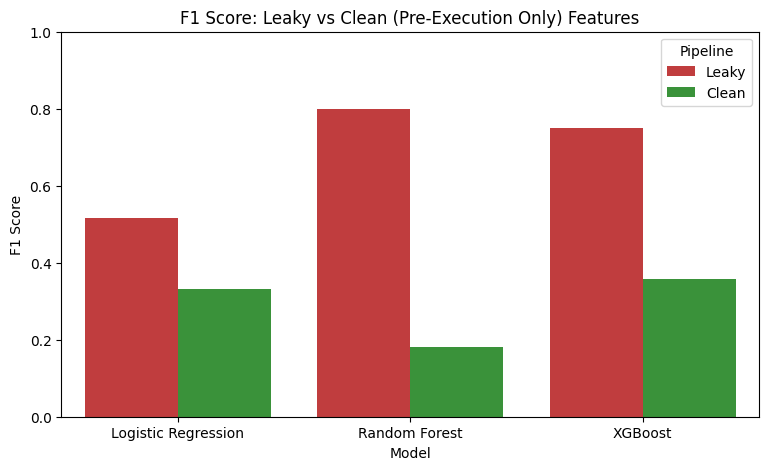

In [3]:
plt.figure(figsize=(9,5))
sns.barplot(data=results, x='Model', y='F1', hue='Pipeline', palette=['#d62728','#2ca02c'])
plt.title('F1 Score: Leaky vs Clean (Pre-Execution Only) Features')
plt.ylabel('F1 Score')
plt.ylim(0, 1)
plt.legend(title='Pipeline')
plt.savefig('/content/drive/MyDrive/software-build-failure-prediction/results/figures/f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

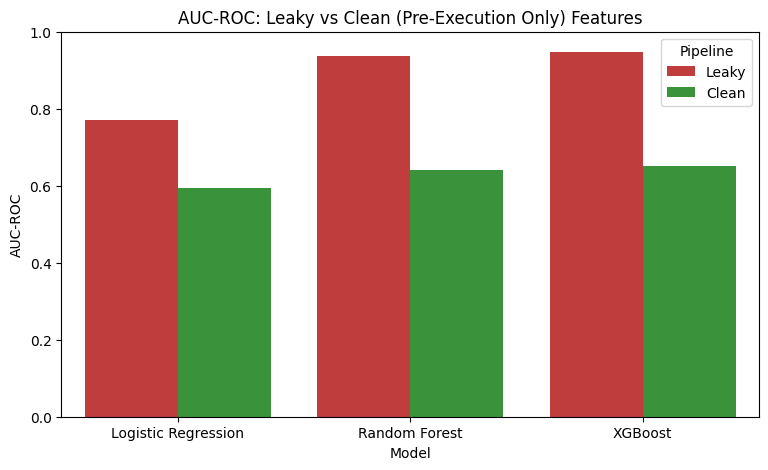

In [ ]:
plt.figure(figsize=(9,5))
sns.barplot(data=results, x='Model', y='AUC-ROC', hue='Pipeline', palette=['#d62728','#2ca02c'])
plt.title('AUC-ROC: Leaky vs Clean (Pre-Execution Only) Features')
plt.ylabel('AUC-ROC')
plt.ylim(0, 1)
plt.legend(title='Pipeline')
plt.savefig('/content/drive/MyDrive/software-build-failure-prediction/results/figures/auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

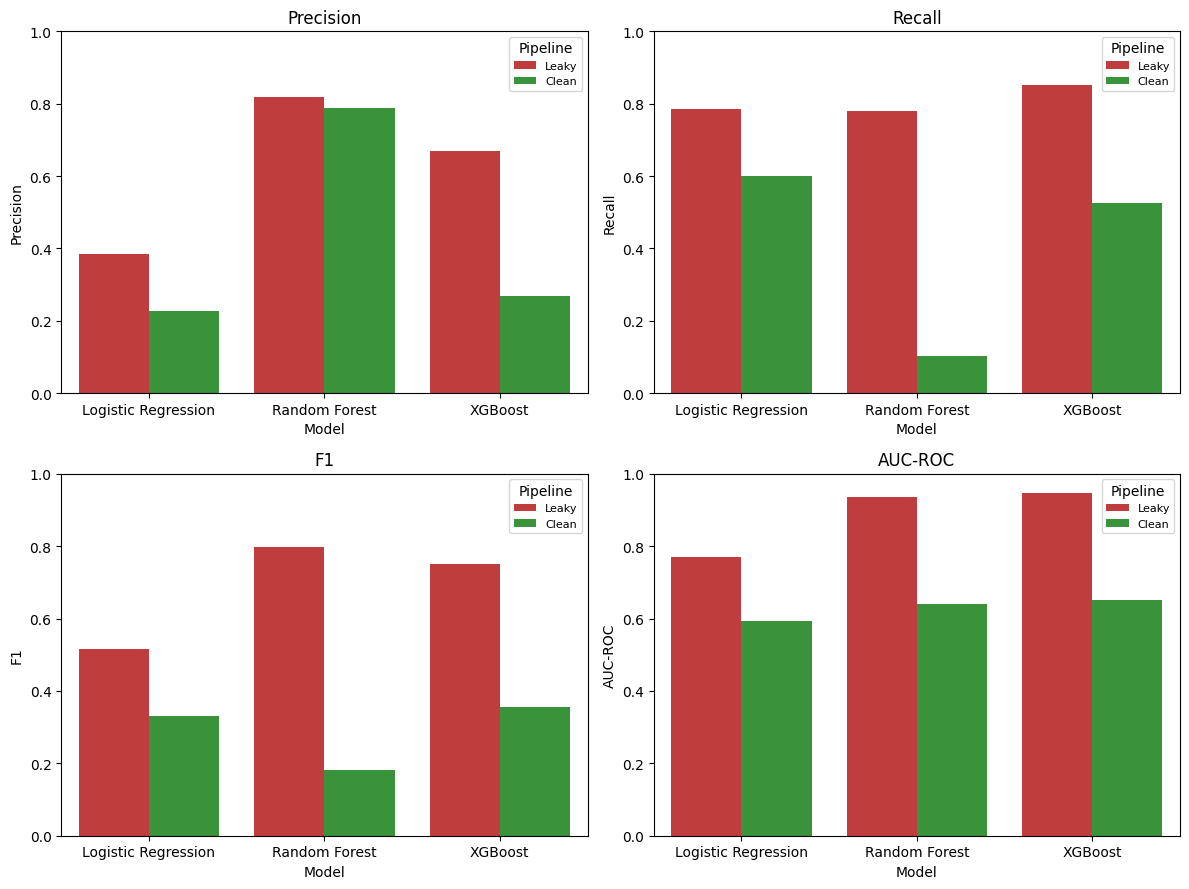

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12,9))
metrics = ['Precision', 'Recall', 'F1', 'AUC-ROC']

for ax, metric in zip(axes.flat, metrics):
    sns.barplot(data=results, x='Model', y=metric, hue='Pipeline', ax=ax, palette=['#d62728','#2ca02c'])
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.legend(title='Pipeline', fontsize=8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/software-build-failure-prediction/results/figures/all_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
pivot_f1 = results.pivot(index='Model', columns='Pipeline', values='F1')
pivot_f1['F1_drop_%'] = ((pivot_f1['Leaky'] - pivot_f1['Clean']) / pivot_f1['Leaky']) * 100

pivot_auc = results.pivot(index='Model', columns='Pipeline', values='AUC-ROC')
pivot_auc['AUC_drop_%'] = ((pivot_auc['Leaky'] - pivot_auc['Clean']) / pivot_auc['Leaky']) * 100

print('F1 drop from Leaky to Clean:')
print(pivot_f1)
print('\nAUC-ROC drop from Leaky to Clean:')
print(pivot_auc)

F1 drop from Leaky to Clean:
Pipeline                Clean     Leaky  F1_drop_%
Model                                             
Logistic Regression  0.331000  0.516780  35.949631
Random Forest        0.181285  0.798734  77.303487
XGBoost              0.356493  0.750591  52.504991

AUC-ROC drop from Leaky to Clean:
Pipeline                Clean     Leaky  AUC_drop_%
Model                                              
Logistic Regression  0.594406  0.769678   22.772188
Random Forest        0.640256  0.936568   31.638035
XGBoost              0.651884  0.947054   31.167189


In [6]:
rf_clean_model = joblib.load('/content/drive/MyDrive/software-build-failure-prediction/results/rf_clean_model.pkl')
xgb_clean_model = joblib.load('/content/drive/MyDrive/software-build-failure-prediction/results/xgb_clean_model.pkl')
feature_names = joblib.load('/content/drive/MyDrive/software-build-failure-prediction/results/clean_feature_names.pkl')

rf_importance = pd.Series(rf_clean_model.feature_importances_, index=feature_names).sort_values(ascending=False)
xgb_importance = pd.Series(xgb_clean_model.feature_importances_, index=feature_names).sort_values(ascending=False)

print('Random Forest top features:')
print(rf_importance.head(10))
print('\nXGBoost top features:')
print(xgb_importance.head(10))

Random Forest top features:
tr_build_number                    0.115311
gh_repo_num_commits                0.111885
gh_repo_age                        0.109411
gh_sloc                            0.098445
gh_test_lines_per_kloc             0.093288
gh_asserts_cases_per_kloc          0.089554
gh_test_cases_per_kloc             0.087249
gh_num_commits_on_files_touched    0.067203
gh_team_size                       0.048324
git_branch                         0.038374
dtype: float64

XGBoost top features:
git_branch                           0.085773
gh_diff_src_files                    0.079814
git_prev_commit_resolution_status    0.075716
gh_sloc                              0.073159
gh_repo_num_commits                  0.070640
gh_team_size                         0.061571
gh_test_lines_per_kloc               0.061358
tr_build_number                      0.060395
gh_test_cases_per_kloc               0.058883
gh_repo_age                          0.058636
dtype: float32


In [7]:
final_table = results.pivot(index='Model', columns='Pipeline', values=['Precision','Recall','F1','AUC-ROC'])
final_table = final_table.round(3)
print(final_table)

final_table.to_csv('/content/drive/MyDrive/software-build-failure-prediction/results/final_summary_table.csv')
print('\nSaved as final_summary_table.csv — open this in Excel/Sheets to format a nice table for your report.')

                    Precision        Recall            F1        AUC-ROC  \
Pipeline                Clean  Leaky  Clean  Leaky  Clean  Leaky   Clean   
Model                                                                      
Logistic Regression     0.229  0.385  0.600  0.784  0.331  0.517   0.594   
Random Forest           0.787  0.819  0.102  0.779  0.181  0.799   0.640   
XGBoost                 0.270  0.670  0.524  0.853  0.356  0.751   0.652   

                            
Pipeline             Leaky  
Model                       
Logistic Regression  0.770  
Random Forest        0.937  
XGBoost              0.947  

Saved as final_summary_table.csv — open this in Excel/Sheets to format a nice table for your report.
